# SIS threshold analysis (NetLogo → CSV → Python)

Loads `output/lambda_max.csv` and BehaviorSpace `output/raw/*_table.csv` files produced by:

`python scripts/run_pipeline.py --all`

Requires NetLogo 7 and `NETLOGO_HOME` pointing at the install folder.

**Cursor:** use the kernel **RMAI (.conda)** (see `.vscode/settings.json`). Run `pip install -r requirements.txt` in `.conda` if imports fail.

BehaviorSpace: use **Tools → BehaviorSpace → Import** `netlogo/behaviorspace_experiments.xml`, or run headless via `scripts/run_pipeline.py` (no import needed).

**Research-question tooling (points 1–5):** (1) $\hat\beta$ from **survival** ($\mathbb{P}(\text{not extinct})$) and from **logit** ED50; legacy column uses late-prevalence persistence. (2) ER baseline **05–07** use a fine $\beta$ grid in XML; pilot experiments **02–04** use a coarser sweep to `0.56`. (3) Bootstrap 95% CI for $\hat\beta_{\mathrm{surv},50}$. (4) **grp-SIS (Tang et al.):** recovery choosers `lognormal (Tang)` and `power law (Tang)` in `virus_simulation.nlogox`; experiments `03-threshold-power-law-Tang`, `04-threshold-lognormal-Tang` (matched $\mathbb{E}[W]$ via `recovery-mean`). (5) **Timing:** medians of `bs-out-final-tick` when extinct vs survive. See `scripts/threshold_estimators.py`.

**Paper outputs:** `python scripts/run_pipeline.py --all` runs NetLogo and then `aggregate_thresholds` to write `empirical_thresholds.csv`, `threshold_ratio_summary.csv`, `threshold_ratio_by_run.csv`, and `threshold_ratio_bar.png`. In the notebook you can re-run the same aggregation cells to refresh plots after manual BehaviorSpace exports.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "NetLogo" / "virus_simulation.nlogox").is_file():
            return p
    raise FileNotFoundError(
        "Could not find NetLogo/virus_simulation.nlogox. Open the repo root in Cursor (File → Open Folder)."
    )


ROOT = _project_root()
sys.path.insert(0, str(ROOT))

import importlib

import scripts.analysis_utils as _analysis_utils

importlib.reload(_analysis_utils)
net_label_from_network_type = _analysis_utils.net_label_from_network_type
net_label_from_behaviorspace = _analysis_utils.net_label_from_behaviorspace
read_behaviorspace_table = _analysis_utils.read_behaviorspace_table
pick_column = getattr(_analysis_utils, "pick_column", None)
if pick_column is None:
    import re as _re

    def _normalize_column_key(name: object) -> str:
        return (
            _re.sub(r"\s+", "_", str(name).strip().strip('"').lower())
            .replace("[", "")
            .replace("]", "")
            .replace("-", "_")
        )

    def pick_column(df: pd.DataFrame, *candidates: str) -> str | None:
        index = {_normalize_column_key(c): c for c in df.columns}
        for cand in candidates:
            k = _normalize_column_key(cand)
            if k in index:
                return index[k]
        return None

import scripts.threshold_estimators as _threshold_estimators

importlib.reload(_threshold_estimators)
row_threshold_summary = _threshold_estimators.row_threshold_summary
survival_curve = _threshold_estimators.survival_curve

OUT = ROOT / "output"
RAW = OUT / "raw"
LAMBDA_PATH = OUT / "lambda_max.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
ROOT

WindowsPath('C:/Dossiers/Master AI/Research Methods for AI (IM1312)/RMAI Research Project')

In [2]:
from scripts.aggregate_thresholds import recovery_regime_from_path


def load_threshold_tables(raw_dir: Path) -> pd.DataFrame:
    frames = []
    for path in sorted(raw_dir.glob("*_table.csv")):
        if "01-export" in path.name:
            continue
        df = read_behaviorspace_table(path)
        df["recovery_regime"] = recovery_regime_from_path(path)
        df["source_file"] = path.name
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No threshold tables in {raw_dir}")
    return pd.concat(frames, ignore_index=True)


if not LAMBDA_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {LAMBDA_PATH}. Run: python scripts/run_pipeline.py --all (after 01-export-networks)."
    )

lam = pd.read_csv(LAMBDA_PATH)
lam["net_label"] = lam["net_label"].astype(str)
lam["random_seed"] = lam["random_seed"].astype(int)

runs = load_threshold_tables(RAW)
# Network identifier: prefer explicit interconnection structure (Lattice4, Ring),
# fall back to legacy network-type if needed.
net_col = pick_column(
    runs,
    "interconnection_structure",
    "interconnection-structure",
    "network_type",
    "network-type",
)
seed_col = pick_column(
    runs, "expt_seed", "expt-seed", "run_seed", "run-seed", "random_seed", "random-seed"
)
inf_col = pick_column(
    runs, "infection_prob", "infection-prob", "infection prob", "[infection-prob]"
)
ext_col = pick_column(runs, "bs_out_extinct", "bs-out-extinct")
prev_col = pick_column(runs, "bs_out_late_mean_prevalence", "bs-out-late-mean-prevalence")
tick_col = pick_column(runs, "bs_out_final_tick", "bs-out-final-tick")
tau_col = pick_column(runs, "bs_out_tau_sim", "bs-out-tau-sim")
rm_col = pick_column(runs, "recovery_mean", "recovery-mean")
type_col = pick_column(runs, "network_type", "network-type")

missing = [n for n, c in [
    ("network_type", net_col),
    ("random_seed", seed_col),
    ("infection_prob", inf_col),
    ("extinct metric", ext_col),
    ("late prevalence", prev_col),
] if c is None]
if missing:
    raise KeyError(f"Could not resolve columns: {missing}. Available: {list(runs.columns)}")

runs["net_label"] = runs.apply(
    lambda row: net_label_from_behaviorspace(
        str(row[net_col]), row.get(type_col) if type_col else None
    ),
    axis=1,
)
runs["random_seed"] = runs[seed_col].astype(int)

_lam_merge = ["net_label", "random_seed", "lambda_max"]
for _c in ("k_mean", "k2_mean", "tau_pred_homogeneous_mf", "tau_pred_heterogeneous_mf"):
    if _c in lam.columns:
        _lam_merge.append(_c)
merged = runs.merge(lam[_lam_merge], on=["net_label", "random_seed"], how="left")
merged[inf_col] = pd.to_numeric(merged[inf_col], errors="coerce")
ew = float(merged[rm_col].dropna().iloc[0]) if rm_col else 5.0
merged["beta_pred"] = 1.0 / (merged["lambda_max"] * ew)
merged["tau_pred_spectral"] = merged["beta_pred"] * ew  # == 1/lambda_max by construction
merged["tau_pred"] = merged["tau_pred_spectral"]  # alias (same as old name)
if "tau_pred_homogeneous_mf" in merged.columns:
    merged["beta_pred_homogeneous_mf"] = merged["tau_pred_homogeneous_mf"] / ew
if "tau_pred_heterogeneous_mf" in merged.columns:
    merged["beta_pred_heterogeneous_mf"] = merged["tau_pred_heterogeneous_mf"] / ew

print("Loaded threshold tables and merged with lambda_max.")
merged.head()

# baseline empirical threshold (ER, exponential)
recovery_mean_baseline = ew  # must match recovery_mean in NetLogo

if (lam["net_label"] == "ER").any():
    er_row = lam.query("net_label == 'ER'").iloc[0]
    lambda_max_er = float(er_row["lambda_max"])

    tau_c_pred = 1.0 / lambda_max_er
    beta_c_pred = tau_c_pred / recovery_mean_baseline

    multipliers = np.array([0.50, 0.75, 1.00, 1.25, 1.50])
    beta_values = multipliers * beta_c_pred

    print("=== baseline empirical threshold (ER, exponential) ===")
    print(f"lambda_max (ER)              = {lambda_max_er:.6f}")
    print(f"E[W] (recovery_mean)        = {recovery_mean_baseline:.3f}")
    print(f"tau_c^pred = 1/lambda_max   = {tau_c_pred:.6f}")
    print(f"beta_c^pred = tau_c^pred/E[W] = {beta_c_pred:.6f}")
    print()
    print("BehaviorSpace infection_prob values (multipliers * beta_c^pred):")
    print("multipliers:", multipliers)
    beta_strs = ["{:.6f}".format(float(b)) for b in beta_values]
    print("beta-values:", beta_strs)
    print()
    print("Paste into BehaviorSpace infection_prob:")
    print(" ".join(beta_strs))
else:
    print("No ER row found in lambda_max.csv; run ER network export + lambda_max first.")

Loaded threshold tables and merged with lambda_max.
=== baseline empirical threshold (ER, exponential) ===
lambda_max (ER)              = 7.180628
E[W] (recovery_mean)        = 5.000
tau_c^pred = 1/lambda_max   = 0.139264
beta_c^pred = tau_c^pred/E[W] = 0.027853

BehaviorSpace infection_prob values (multipliers * beta_c^pred):
multipliers: [0.5  0.75 1.   1.25 1.5 ]
beta-values: ['0.013926', '0.020890', '0.027853', '0.034816', '0.041779']

Paste into BehaviorSpace infection_prob:
0.013926 0.020890 0.027853 0.034816 0.041779


In [3]:
def persistence_score(g: pd.DataFrame) -> pd.Series:
    """Fraction of replicates that survive with late prevalence > 1e-4."""
    survived = (g[ext_col] < 0.5) & (g[prev_col] > 1e-4)
    return pd.Series({"p_persist": survived.mean(), "n": len(g)})


def summarize_curves(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["recovery_regime", "net_label", "random_seed", inf_col]
    for key, g in frame.groupby(group_cols):
        s = persistence_score(g)
        row = dict(zip(group_cols, key if isinstance(key, tuple) else (key,)))
        row["p_persist"] = s["p_persist"]
        row["n"] = int(s["n"])
        rows.append(row)
    return pd.DataFrame(rows)


summary = summarize_curves(merged)
_agg: dict[str, tuple[str, str]] = {"beta_pred": ("beta_pred", "first")}
if "beta_pred_homogeneous_mf" in merged.columns:
    _agg["beta_pred_homogeneous_mf"] = ("beta_pred_homogeneous_mf", "first")
if "beta_pred_heterogeneous_mf" in merged.columns:
    _agg["beta_pred_heterogeneous_mf"] = ("beta_pred_heterogeneous_mf", "first")
beta_pred_sub = merged.groupby(["recovery_regime", "net_label", "random_seed"], as_index=False).agg(
    **_agg
)
curve = summary.merge(beta_pred_sub, on=["recovery_regime", "net_label", "random_seed"])
curve.head()

,recovery_regime,net_label,random_seed,infection_prob,p_persist,n,beta_pred,beta_pred_homogeneous_mf,beta_pred_heterogeneous_mf
0,exponential,ER,10001,0.018,0.0,24,0.027853,0.03345,0.028565
1,exponential,ER,10001,0.020,0.0,24,0.027853,0.03345,0.028565
2,exponential,ER,10001,0.022,0.0,24,0.027853,0.03345,0.028565
3,exponential,ER,10001,0.024,0.0,24,0.027853,0.03345,0.028565
4,exponential,ER,10001,0.026,0.0,24,0.027853,0.03345,0.028565


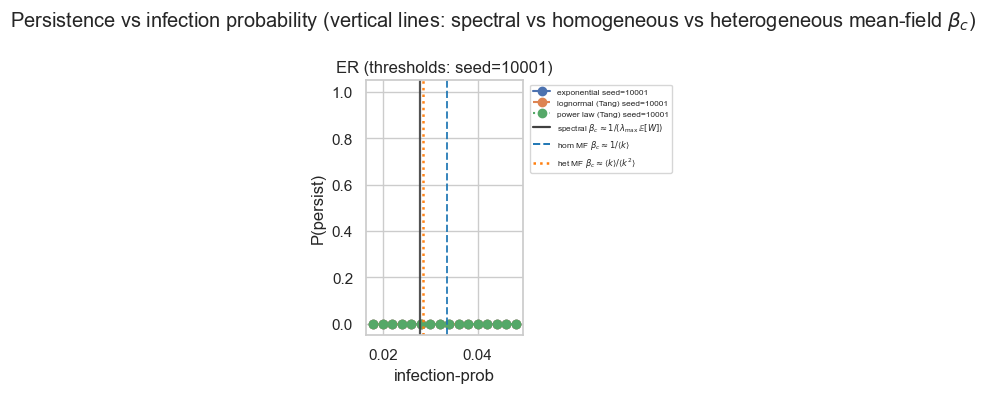

In [4]:
from itertools import cycle
from matplotlib.lines import Line2D

# Determine which network labels are actually present in the data.
# Fall back to whatever is in the curve if the original ER/WS/BA trio is absent.
preferred = ["ER", "WS", "BA", "Lat4", "Ring"]
present = list(curve["net_label"].unique())
nets = [n for n in preferred if n in present] or sorted(present)

fig, axes = plt.subplots(1, max(len(nets), 1), figsize=(4 * max(len(nets), 1), 4), sharey=True)
if len(nets) <= 1:
    axes = np.array([axes])
thresh_legend_handles = [
    Line2D([0], [0], color="0.25", linestyle="-", linewidth=1.6),
    Line2D([0], [0], color="tab:blue", linestyle="--", linewidth=1.4),
    Line2D([0], [0], color="tab:orange", linestyle=":", linewidth=1.8),
]
thresh_legend_labels = [
    r"spectral $\beta_c \approx 1/(\lambda_{\max}\,\mathbb{E}[W])$",
    r"hom MF $\beta_c \approx 1/\langle k\rangle$",
    r"het MF $\beta_c \approx \langle k\rangle/\langle k^2\rangle$",
]
for ax, net in zip(axes, nets):
    sub = curve[curve["net_label"] == net]
    if sub.empty:
        continue
    for reg, sty in zip(sub["recovery_regime"].unique(), cycle(["-", "--", ":", "-."])):
        g = sub[sub["recovery_regime"] == reg]
        for seed, m in zip(sorted(g["random_seed"].unique()), ["o", "s", "^"]):
            gg = g[g["random_seed"] == seed].sort_values(inf_col)
            ax.plot(
                gg[inf_col],
                gg["p_persist"],
                marker=m,
                linestyle=sty,
                label=f"{reg} seed={seed}",
            )
    seed0 = sorted(sub["random_seed"].unique())[0]
    row0 = sub[sub["random_seed"] == seed0].iloc[0]
    ax.axvline(row0["beta_pred"], color="0.25", linestyle="-", linewidth=1.6, alpha=0.9)
    if "beta_pred_homogeneous_mf" in sub.columns and pd.notna(row0.get("beta_pred_homogeneous_mf")):
        ax.axvline(
            row0["beta_pred_homogeneous_mf"],
            color="tab:blue",
            linestyle="--",
            linewidth=1.4,
            alpha=0.9,
        )
    if "beta_pred_heterogeneous_mf" in sub.columns and pd.notna(row0.get("beta_pred_heterogeneous_mf")):
        ax.axvline(
            row0["beta_pred_heterogeneous_mf"],
            color="tab:orange",
            linestyle=":",
            linewidth=1.8,
            alpha=0.95,
        )
    h_curve, lab_curve = ax.get_legend_handles_labels()
    n_thr = min(
        len(thresh_legend_handles),
        1
        + int(
            "beta_pred_homogeneous_mf" in sub.columns
            and pd.notna(row0.get("beta_pred_homogeneous_mf"))
        )
        + int(
            "beta_pred_heterogeneous_mf" in sub.columns
            and pd.notna(row0.get("beta_pred_heterogeneous_mf"))
        ),
    )
    ax.legend(
        h_curve + thresh_legend_handles[:n_thr],
        lab_curve + thresh_legend_labels[:n_thr],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=6,
    )
    ax.set_title(f"{net} (thresholds: seed={seed0})")
    ax.set_xlabel("infection-prob")
    ax.set_ylim(-0.05, 1.05)
axes[0].set_ylabel("P(persist)")
fig.suptitle(
    "Persistence vs infection probability (vertical lines: spectral vs homogeneous vs heterogeneous mean-field $\\beta_c$)"
)
plt.tight_layout()
plt.show()


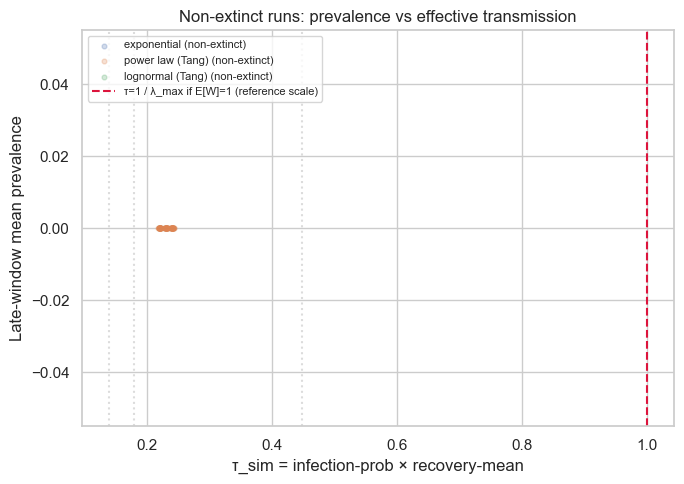

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for reg in merged["recovery_regime"].unique():
    sub = merged[merged["recovery_regime"] == reg]
    if tau_col:
        x = sub[tau_col]
        xlab = "τ_sim = infection-prob × recovery-mean"
    else:
        x = sub[inf_col] * ew
        xlab = "τ_sim (reconstructed)"
    jitter = np.random.default_rng(0).normal(0, 0.01 * (x.max() - x.min() + 1e-6), size=len(x))
    y = sub[prev_col].to_numpy()
    c = sub[ext_col].to_numpy()
    mask = c < 0.5
    ax.scatter(x[mask] + jitter[mask], y[mask], alpha=0.25, s=12, label=f"{reg} (non-extinct)")
for _, row in lam.iterrows():
    ax.axvline(1.0 / row["lambda_max"], color="k", linestyle=":", alpha=0.15)
ax.axvline(1.0, color="crimson", linestyle="--", label="τ=1 / λ_max if E[W]=1 (reference scale)")
ax.set_xlabel(xlab)
ax.set_ylabel("Late-window mean prevalence")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Non-extinct runs: prevalence vs effective transmission")
plt.tight_layout()
plt.show()

In [6]:
# Empirical thresholds (points 1-5): survival-based beta_hat, bootstrap CIs, logit ED50, persistence, extinction timing
N_BOOT = 400


def empirical_threshold_legacy(sub_df: pd.DataFrame, q: float = 0.5) -> float:
    if sub_df.empty or inf_col not in sub_df.columns:
        return float("nan")
    rows = []
    for beta, g in sub_df.groupby(inf_col, dropna=False):
        s = persistence_score(g)
        rows.append({inf_col: beta, "p_persist": s["p_persist"]})
    if not rows:
        return float("nan")
    g2 = pd.DataFrame(rows).sort_values(inf_col, na_position="last")
    above = g2[g2["p_persist"] >= q]
    if above.empty:
        mx = g2[inf_col].max()
        return float(mx) if pd.notna(mx) else float("nan")
    return float(above.iloc[0][inf_col])


rows_out = []
for (reg, net, seed), sub in merged.groupby(["recovery_regime", "net_label", "random_seed"]):
    beta_p = float(sub["beta_pred"].iloc[0])
    summ = row_threshold_summary(
        sub,
        inf_col,
        ext_col,
        prev_col,
        tick_col,
        beta_pred=beta_p,
        n_boot=N_BOOT,
    )
    summ["recovery_regime"] = reg
    summ["net_label"] = net
    summ["random_seed"] = seed
    summ["beta_hat_50_legacy_persist"] = empirical_threshold_legacy(sub)
    summ["ratio_legacy_over_pred"] = summ["beta_hat_50_legacy_persist"] / beta_p if beta_p else float("nan")
    rows_out.append(summ)

thresh_tbl = pd.DataFrame(rows_out)
cols = [
    "recovery_regime",
    "net_label",
    "random_seed",
    "beta_pred",
    "beta_hat_surv_50",
    "beta_hat_surv_25",
    "beta_hat_surv_50_median_boot",
    "beta_hat_surv_50_ci_low",
    "beta_hat_surv_50_ci_high",
    "beta_hat_logit_ed50_surv",
    "beta_hat_persist_50",
    "beta_hat_persist_relaxed_50",
    "median_tick_if_extinct",
    "median_tick_if_survive",
    "ratio_surv_50_over_pred",
    "beta_hat_50_legacy_persist",
    "ratio_legacy_over_pred",
]
cols = [c for c in cols if c in thresh_tbl.columns]
thresh_tbl = thresh_tbl[cols]
thresh_tbl.to_csv(OUT / "empirical_thresholds.csv", index=False)
print("Saved", OUT / "empirical_thresholds.csv")
thresh_tbl.head(12)


Saved C:\Dossiers\Master AI\Research Methods for AI (IM1312)\RMAI Research Project\output\empirical_thresholds.csv


,recovery_regime,net_label,random_seed,beta_pred,beta_hat_surv_50,beta_hat_surv_25,beta_hat_surv_50_median_boot,beta_hat_surv_50_ci_low,beta_hat_surv_50_ci_high,beta_hat_logit_ed50_surv,beta_hat_persist_50,beta_hat_persist_relaxed_50,median_tick_if_extinct,median_tick_if_survive,ratio_surv_50_over_pred,beta_hat_50_legacy_persist,ratio_legacy_over_pred
0,exponential,ER,10001,0.027853,0.048,0.048,0.048,0.048,0.048,NaN,0.048,0.048,8.0,NaN,1.723351,0.048,1.723351
1,lognormal (Tang),ER,10001,0.027853,0.048,0.048,0.048,0.048,0.048,NaN,0.048,0.048,9.0,NaN,1.723351,0.048,1.723351
2,power law (Tang),ER,10001,0.027853,0.044,0.044,0.044,0.044,0.044,NaN,0.048,0.048,15.0,10000.0,1.579738,0.048,1.723351


## Research question: $\hat\beta_{50} / \beta_c^{\mathrm{pred}}$

Paper-ready summary: ratio of survival-based threshold $\hat\beta_{\mathrm{surv}\,50}$ to the spectral prediction $\beta_{\mathrm{pred}} = 1/(\lambda_{\max}\,\mathbb{E}[W])$, by **network** and **recovery regime** (exponential vs Tang power law vs Tang lognormal). CSVs and a bar chart are written under `output/`.

Saved C:\Dossiers\Master AI\Research Methods for AI (IM1312)\RMAI Research Project\output\threshold_ratio_by_run.csv
Saved C:\Dossiers\Master AI\Research Methods for AI (IM1312)\RMAI Research Project\output\threshold_ratio_summary.csv


,recovery_regime,net_label,ratio_mean,ratio_std,n_seeds
0,exponential,ER,1.723351,NaN,1
1,lognormal (Tang),ER,1.723351,NaN,1
2,power law (Tang),ER,1.579738,NaN,1


Saved C:\Dossiers\Master AI\Research Methods for AI (IM1312)\RMAI Research Project\output\threshold_ratio_bar.png


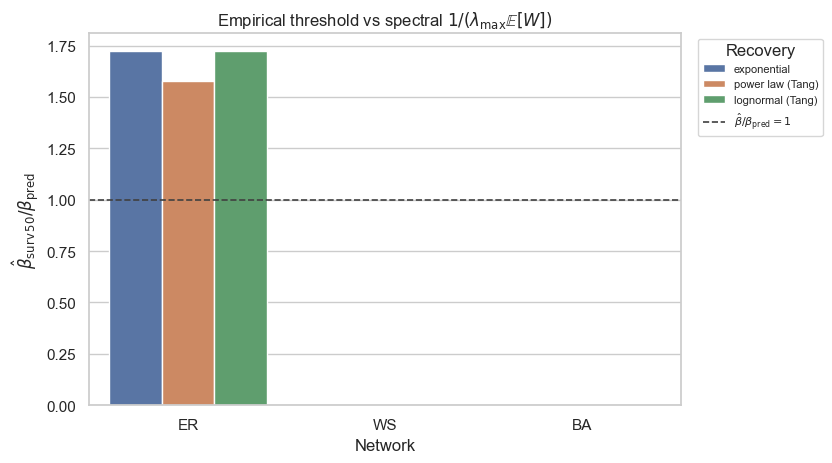

In [7]:
# β̂_surv,50 / β_pred: table + bar figure (report / paper)
_regimes_paper = ["exponential", "power law (Tang)", "lognormal (Tang)"]
_net_order = ["ER", "WS", "BA"]

_t = pd.read_csv(OUT / "empirical_thresholds.csv")
_t = _t[_t["recovery_regime"].isin(_regimes_paper)].copy()
_t["ratio_ci_low"] = _t["beta_hat_surv_50_ci_low"] / _t["beta_pred"]
_t["ratio_ci_high"] = _t["beta_hat_surv_50_ci_high"] / _t["beta_pred"]

_cols = [
    "recovery_regime",
    "net_label",
    "random_seed",
    "beta_pred",
    "beta_hat_surv_50",
    "beta_hat_surv_50_ci_low",
    "beta_hat_surv_50_ci_high",
    "ratio_surv_50_over_pred",
    "ratio_ci_low",
    "ratio_ci_high",
    "beta_hat_logit_ed50_surv",
]
_cols = [c for c in _cols if c in _t.columns]
_ratio_by_run = _t[_cols].sort_values(["recovery_regime", "net_label", "random_seed"])
_ratio_by_run.to_csv(OUT / "threshold_ratio_by_run.csv", index=False)

_agg = (
    _t.groupby(["recovery_regime", "net_label"], as_index=False)
    .agg(
        ratio_mean=("ratio_surv_50_over_pred", "mean"),
        ratio_std=("ratio_surv_50_over_pred", "std"),
        n_seeds=("random_seed", "count"),
    )
)
_agg["net_label"] = pd.Categorical(_agg["net_label"], categories=_net_order, ordered=True)
_agg = _agg.sort_values(["recovery_regime", "net_label"]).reset_index(drop=True)
_agg.to_csv(OUT / "threshold_ratio_summary.csv", index=False)

print("Saved", OUT / "threshold_ratio_by_run.csv")
print("Saved", OUT / "threshold_ratio_summary.csv")
display(_agg)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
_palette = {
    "exponential": "C0",
    "power law (Tang)": "C1",
    "lognormal (Tang)": "C2",
}
sns.barplot(
    data=_t,
    x="net_label",
    y="ratio_surv_50_over_pred",
    hue="recovery_regime",
    order=_net_order,
    hue_order=_regimes_paper,
    palette=[_palette[r] for r in _regimes_paper],
    errorbar="sd",
    capsize=0.08,
    ax=ax,
)
ax.axhline(1.0, color="0.25", linestyle="--", lw=1.2, label=r"$\hat{\beta}/\beta_{\mathrm{pred}} = 1$")
ax.set_xlabel("Network")
ax.set_ylabel(r"$\hat{\beta}_{\mathrm{surv}\,50} / \beta_{\mathrm{pred}}$")
ax.set_title(r"Empirical threshold vs spectral $1/(\lambda_{\max}\mathbb{E}[W])$")
ax.legend(title="Recovery", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
_fig_path = OUT / "threshold_ratio_bar.png"
fig.savefig(_fig_path, dpi=150, bbox_inches="tight")
print("Saved", _fig_path)
plt.show()

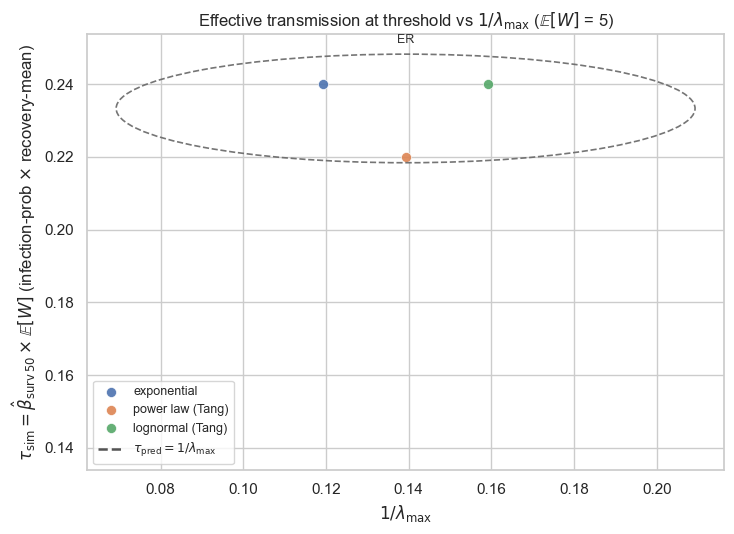

In [8]:
# τ_sim = infection-prob × E[W] at empirical threshold vs 1/λ_max; reference τ_pred = 1/λ_max (diagonal y = x)
from scipy import stats
import matplotlib.patches as mpatches

_regimes_thr = ["exponential", "power law (Tang)", "lognormal (Tang)"]
_eth = pd.read_csv(OUT / "empirical_thresholds.csv")
_lam = pd.read_csv(LAMBDA_PATH)[["net_label", "random_seed", "lambda_max"]]
_eth["net_label"] = _eth["net_label"].astype(str)
_lam["net_label"] = _lam["net_label"].astype(str)
_corr = _eth[_eth["recovery_regime"].isin(_regimes_thr)].merge(_lam, on=["net_label", "random_seed"], how="left")
_corr = _corr.dropna(subset=["beta_hat_surv_50", "lambda_max"])
_corr["inv_lambda_max"] = 1.0 / _corr["lambda_max"]
# E[W] from spectral identity β_pred = 1/(λ_max · E[W])
_ew = float((1.0 / (_corr["beta_pred"] * _corr["lambda_max"])).iloc[0])
_corr["tau_hat"] = _corr["beta_hat_surv_50"] * _ew
_corr["tau_pred"] = _corr["inv_lambda_max"]  # == β_pred · E[W] = 1/λ_max

fig, ax = plt.subplots(figsize=(7.5, 5.5))
_colors = {"exponential": "C0", "power law (Tang)": "C1", "lognormal (Tang)": "C2"}
_offset_idx = {"exponential": -1, "power law (Tang)": 0, "lognormal (Tang)": 1}
_span = float(_corr["inv_lambda_max"].max() - _corr["inv_lambda_max"].min()) if not _corr.empty else 0.0
_dx = 0.02 * (_span if _span > 0 else 1.0)
for _reg in _regimes_thr:
    sub = _corr[_corr["recovery_regime"] == _reg]
    if sub.empty:
        continue
    _x = sub["inv_lambda_max"] + _dx * _offset_idx.get(_reg, 0)
    ax.scatter(
        _x,
        sub["tau_hat"],
        label=_reg,
        alpha=0.9,
        s=52,
        c=_colors.get(_reg, "0.3"),
        edgecolors="white",
        linewidths=0.5,
    )
    if len(sub) >= 2:
        r, p = stats.pearsonr(sub["inv_lambda_max"], sub["tau_hat"])
        print(f"{_reg}: Pearson r(1/λ_max, τ̂) = {r:.3f}, p = {p:.3g}, n = {len(sub)}")

# Highlight clusters per network with an ellipse and label
if not _corr.empty:
    span_x = float(_corr["inv_lambda_max"].max() - _corr["inv_lambda_max"].min()) or 1.0
    span_y = float(_corr["tau_hat"].max() - _corr["tau_hat"].min()) or 1.0
    pad_x = 0.05 * span_x
    pad_y = 0.08 * span_y
    for _net in sorted(_corr["net_label"].dropna().unique()):
        sub_n = _corr[_corr["net_label"] == _net]
        if sub_n.empty:
            continue
        # Use the same jittered x as in the scatter so all points fall inside
        _off = sub_n["recovery_regime"].map(_offset_idx).fillna(0.0)
        x_jit = sub_n["inv_lambda_max"] + _dx * _off
        cx = float(x_jit.mean())
        cy = float(sub_n["tau_hat"].mean())
        dx_max = float((x_jit - cx).abs().max()) or 0.0
        dy_max = float((sub_n["tau_hat"] - cy).abs().max()) or 0.0
        rx = dx_max + pad_x
        ry = dy_max + pad_y
        circ = mpatches.Ellipse(
            (cx, cy),
            width=2 * rx,
            height=2 * ry,
            fill=False,
            linestyle="--",
            linewidth=1.2,
            edgecolor="0.4",
            alpha=0.9,
        )
        ax.add_patch(circ)
        ax.text(
            cx,
            cy + 1.15 * ry,
            _net,
            ha="center",
            va="bottom",
            fontsize=9,
            color="0.2",
        )

if not _corr.empty:
    _xmin, _xmax = _corr["inv_lambda_max"].min(), _corr["inv_lambda_max"].max()
    ax.plot([_xmin, _xmax], [_xmin, _xmax], "k--", lw=1.8, alpha=0.75, label=r"$\tau_{\mathrm{pred}} = 1/\lambda_{\max}$")
ax.set_xlabel(r"$1/\lambda_{\max}$")
ax.set_ylabel(r"$\tau_{\mathrm{sim}} = \hat{\beta}_{\mathrm{surv}\,50} \times \mathbb{E}[W]$ (infection-prob $\times$ recovery-mean)")
ax.set_title(r"Effective transmission at threshold vs $1/\lambda_{\max}$ ($\mathbb{E}[W]$ = " + f"{_ew:.4g})")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

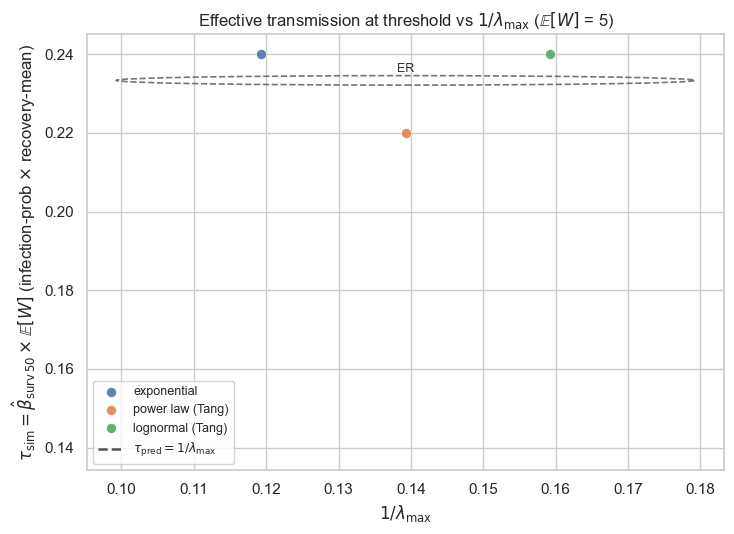

In [9]:
# τ_sim = infection-prob × E[W] at empirical threshold vs 1/λ_max; reference τ_pred = 1/λ_max (diagonal y = x)
# τ_sim = infection-prob × E[W] at empirical threshold vs 1/λ_max; reference τ_pred = 1/λ_max (diagonal y = x)
from scipy import stats
import matplotlib.patches as mpatches
_regimes_thr = ["exponential", "power law (Tang)", "lognormal (Tang)"]
_eth = pd.read_csv(OUT / "empirical_thresholds.csv")
_lam = pd.read_csv(LAMBDA_PATH)[["net_label", "random_seed", "lambda_max"]]
_eth["net_label"] = _eth["net_label"].astype(str)
_lam["net_label"] = _lam["net_label"].astype(str)
_corr = _eth[_eth["recovery_regime"].isin(_regimes_thr)].merge(_lam, on=["net_label", "random_seed"], how="left")
_corr = _corr.dropna(subset=["beta_hat_surv_50", "lambda_max"])
_corr["inv_lambda_max"] = 1.0 / _corr["lambda_max"]
# E[W] from spectral identity β_pred = 1/(λ_max · E[W])
_ew = float((1.0 / (_corr["beta_pred"] * _corr["lambda_max"])).iloc[0])
_corr["tau_hat"] = _corr["beta_hat_surv_50"] * _ew
_corr["tau_pred"] = _corr["inv_lambda_max"]  # == β_pred · E[W] = 1/λ_max
fig, ax = plt.subplots(figsize=(7.5, 5.5))
_colors = {"exponential": "C0", "power law (Tang)": "C1", "lognormal (Tang)": "C2"}
_offset_idx = {"exponential": -1, "power law (Tang)": 0, "lognormal (Tang)": 1}
_span = float(_corr["inv_lambda_max"].max() - _corr["inv_lambda_max"].min()) if not _corr.empty else 0.0
_dx = 0.02 * (_span if _span > 0 else 1.0)
for _reg in _regimes_thr:
    sub = _corr[_corr["recovery_regime"] == _reg]
    if sub.empty:
        continue
    _x = sub["inv_lambda_max"] + _dx * _offset_idx.get(_reg, 0)
    ax.scatter(
        _x,
        sub["tau_hat"],
        label=_reg,
        alpha=0.9,
        s=52,
        c=_colors.get(_reg, "0.3"),
        edgecolors="white",
        linewidths=0.5,
    )
    if len(sub) >= 2:
        r, p = stats.pearsonr(sub["inv_lambda_max"], sub["tau_hat"])
        print(f"{_reg}: Pearson r(1/λ_max, τ̂) = {r:.3f}, p = {p:.3g}, n = {len(sub)}")
# Highlight clusters per network with an ellipse and label
if not _corr.empty:
    span_x = float(_corr["inv_lambda_max"].max() - _corr["inv_lambda_max"].min()) or 1.0
    span_y = float(_corr["tau_hat"].max() - _corr["tau_hat"].min()) or 1.0
    rx = 0.04 * span_x
    ry = 0.06 * span_y
    for _net in sorted(_corr["net_label"].dropna().unique()):
        sub_n = _corr[_corr["net_label"] == _net]
        if sub_n.empty:
            continue
        cx = float(sub_n["inv_lambda_max"].mean())
        cy = float(sub_n["tau_hat"].mean())
        circ = mpatches.Ellipse(
            (cx, cy),
            width=2 * rx,
            height=2 * ry,
            fill=False,
            linestyle="--",
            linewidth=1.2,
            edgecolor="0.4",
            alpha=0.9,
        )
        ax.add_patch(circ)
        ax.text(
            cx,
            cy + 1.15 * ry,
            _net,
            ha="center",
            va="bottom",
            fontsize=9,
            color="0.2",
        )
if not _corr.empty:
    _xmin, _xmax = _corr["inv_lambda_max"].min(), _corr["inv_lambda_max"].max()
    ax.plot([_xmin, _xmax], [_xmin, _xmax], "k--", lw=1.8, alpha=0.75, label=r"$\tau_{\mathrm{pred}} = 1/\lambda_{\max}$")
ax.set_xlabel(r"$1/\lambda_{\max}$")
ax.set_ylabel(r"$\tau_{\mathrm{sim}} = \hat{\beta}_{\mathrm{surv}\,50} \times \mathbb{E}[W]$ (infection-prob $\times$ recovery-mean)")
ax.set_title(r"Effective transmission at threshold vs $1/\lambda_{\max}$ ($\mathbb{E}[W]$ = " + f"{_ew:.4g})")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
print(LAMBDA_PATH)

C:\Dossiers\Master AI\Research Methods for AI (IM1312)\RMAI Research Project\output\lambda_max.csv


In [11]:
# baseline empirical threshold: ER, exponential recovery

# Aanname: lam is al ingelezen uit LAMBDA_PATH (zie eerdere cel)
# en bevat een rij met net_label == "ER" voor jouw ER-configuratie.
lam = pd.read_csv(LAMBDA_PATH)
recovery_mean_baseline = 5.0  # moet overeenkomen met recovery_mean in NetLogo

er_row = lam.query("net_label == 'ER'").iloc[0]
lambda_max_er = float(er_row["lambda_max"])

tau_c_pred = 1.0 / lambda_max_er
beta_c_pred = tau_c_pred / recovery_mean_baseline

multipliers = np.array([0.50, 0.75, 1.00, 1.25, 1.50])
beta_values = multipliers * beta_c_pred

print("=== baseline empirical threshold (ER, exponential) ===")
print(f"λ_max (ER)              = {lambda_max_er:.6f}")
print(f"E[W] (recovery_mean)    = {recovery_mean_baseline:.3f}")
print(f"τ_c^pred = 1/λ_max      = {tau_c_pred:.6f}")
print(f"β_c^pred = τ_c^pred/E[W] = {beta_c_pred:.6f}")
print()
print("BehaviorSpace infection_prob values (multipliers * beta_c^pred):")
print("multipliers:", multipliers)
beta_strs = ["{:.6f}".format(float(b)) for b in beta_values]
print("beta-values:", beta_strs)
print()
print("Paste into BehaviorSpace infection_prob:")
print(" ".join(beta_strs))

=== baseline empirical threshold (ER, exponential) ===
λ_max (ER)              = 7.180628
E[W] (recovery_mean)    = 5.000
τ_c^pred = 1/λ_max      = 0.139264
β_c^pred = τ_c^pred/E[W] = 0.027853

BehaviorSpace infection_prob values (multipliers * beta_c^pred):
multipliers: [0.5  0.75 1.   1.25 1.5 ]
beta-values: ['0.013926', '0.020890', '0.027853', '0.034816', '0.041779']

Paste into BehaviorSpace infection_prob:
0.013926 0.020890 0.027853 0.034816 0.041779
